# Классификация

В этом блокноте мы разберём базовую бинарную классификацию. Начнём с **интуитивного алгоритма k‑ближайших соседей (kNN)**, чтобы «пощупать руками» идею классификации, а затем перейдём к **логистической регрессии** — простой интерпретируемой модели, которая даёт вероятности и линейную решающую границу.

> Идея: мы предсказываем не число, а **класс** (или вероятность класса).


## Постановка задачи

Импортируем некоторые полезные библиотеки:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, RocCurveDisplay,
    precision_recall_curve, auc
)

np.random.seed(42)



Представим, что мы аналитики в медтех‑стартапе. У нас есть данные пациентов по двум признакам (например, **давление** и **уровень холестерина**), и мы хотим предсказать, есть ли **риск заболевания**:

- `0` — риска нет
- `1` — риск есть

Сгенерируем синтетический датасет (в реальности вы бы читали его из файла).

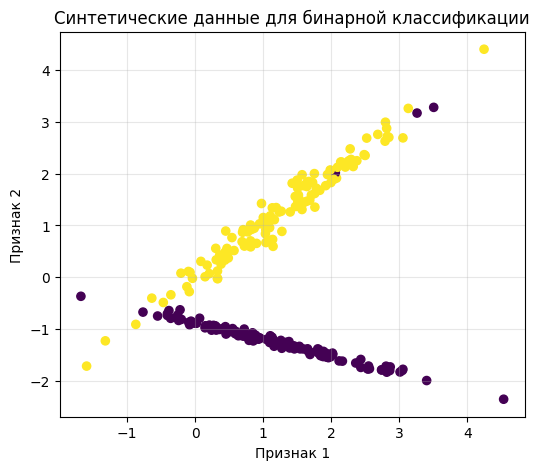

In [ ]:
# Синтетические данные: 2 признака, 2 класса
X, y = make_classification(
    n_samples=250,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.3,
    flip_y=0.05,
    random_state=42
)

# Визуализация
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=35)
plt.title("Синтетические данные для бинарной классификации")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True, alpha=0.3)
plt.show()



**Вопросы:**
* Как предсказать класс для новой точки, если у нас уже есть размеченные примеры?
* Почему в такой задаче естественно говорить про **расстояние** между объектами?
* Что будет, если взять `k=1` и если взять очень большое `k`?

### Ответ

Самый прямой (и очень наглядный) подход — **k‑ближайших соседей (kNN)**.

Идея:
1. Для нового объекта $x$ находим $k$ ближайших объектов из обучающей выборки (обычно по евклидову расстоянию).
2. Смотрим, какие у них классы, и берём **голосование большинства**.

Часто удобно трактовать kNN как оценку вероятности:
$$
\hat P(y=1\mid x)=\frac{1}{k}\sum_{i\in \mathcal N_k(x)} y_i,
$$
то есть доля объектов класса 1 среди $k$ соседей.

Параметр $k$ управляет «гладкостью» границы:
- маленький $k$ ⇒ граница более «рваная» (риск переобучения),
- большой $k$ ⇒ граница более сглаженная (риск недообучения).

---
Минусы kNN: нужно хранить все данные и искать соседей при каждом предсказании. Поэтому дальше перейдём к **параметрической** модели (логистической регрессии).


## kNN: первый классификатор

Используя LLM для генерации кода:
1. Разбейте данные на `train/test` в соотношении `75:25` при помощи `train_test_split` (`random_state=42`, `stratify=y`).
2. Обучите **kNN‑классификатор** `KNeighborsClassifier(n_neighbors=5)`.
3. Так как kNN основан на расстояниях, используйте стандартизацию признаков: `Pipeline(StandardScaler -> KNeighborsClassifier)`.
4. Выведите метрику качества `accuracy` на тесте.


In [ ]:
#TODO

Accuracy (kNN, k=5): 0.9682539682539683


Должно получиться примерно:

- `accuracy: 0.9683`


### Визуализация решающей границы (kNN)

С помощью LLM сгенерируйте код, который построит **решающую границу** (decision boundary) для kNN на плоскости (для 2 признаков).

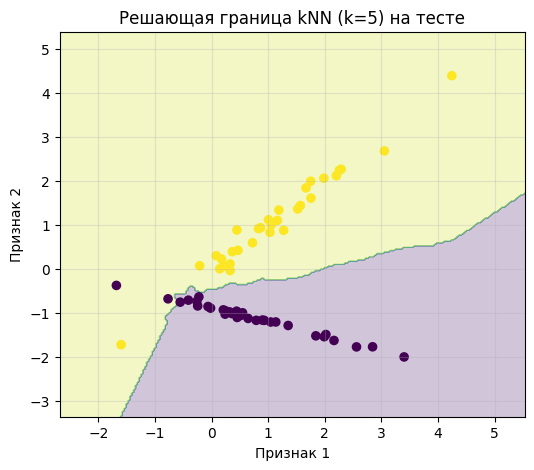

In [ ]:
#TODO


Попробуйте дополнительно поиграться с `n_neighbors` (например, 1, 5, 15) и посмотрите, как меняется качество предсказания и «гладкость» решающей границы.

### **Вопросы**

<details>
<summary><b>Вопрос 1.</b> Почему перед kNN почти всегда делают масштабирование признаков (StandardScaler)?</summary>

Если один признак измеряется «в сотнях» (например, доход), а другой «в долях» (например, доля просрочек), то евклидово расстояние почти полностью будет определяться первым признаком. Масштабирование приводит признаки к сопоставимому масштабу, и расстояние начинает отражать вклад обоих признаков.
</details>

<details>
<summary><b>Вопрос 2.</b> Что произойдёт с границей решений при увеличении <code>k</code>?</summary>

Граница становится более гладкой: модель меньше «подстраивается» под шум (меньше переобучается), но может начать пропускать локальные детали (риск недообучения).
</details>

<details>
<summary><b>Вопрос 3.</b> Можно ли в kNN использовать не евклидово расстояние? Зачем?</summary>

Да. Например, Manhattan (L1), cosine distance, Minkowski и др. Выбор метрики — это способ показать представление о похожести объектов под задачу. Для текстовых эмбеддингов часто естественна косинусная близость; для разреженных признаков иногда лучше L1.
</details>

<details>
<summary><b>Вопрос 4.</b> Почему kNN обычно ухудшается в высокой размерности (много признаков)?</summary>

Срабатывает «проклятие размерности»: в больших размерностях расстояния между точками становятся менее различимыми (почти все «далеко» и «примерно одинаково далеко»). Тогда понятие «ближайшие соседи» теряет смысл, и качество часто падает.
</details>


## Логистическая регрессия

kNN даёт отличное понимание, как можно классифицировать объекты, но в прикладных задачах часто хочется модели, которая:

- быстро предсказывает (несколько скалярных произведений вместо поиска соседей),
- задаёт **интерпретируемую линейную границу**,
- возвращает не только класс, но и **вероятность** класса 1.

Этим требованиям хорошо отвечает **логистическая регрессия**. Её отправная точка — та же геометрия, что и у линейных классификаторов: разделяющая **гиперплоскость**
$$
w^\top x + b = 0.
$$

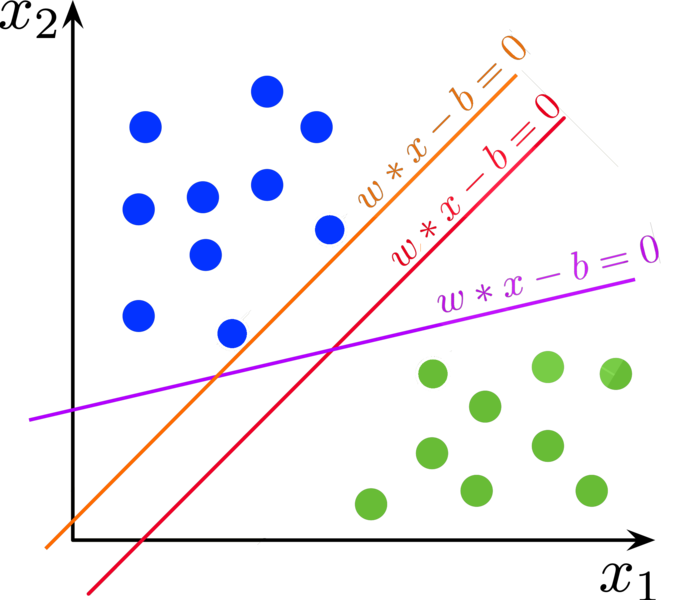

### 1. Линейный скор и положение точки относительно границы

Определим
$$
z = w^\top x + b
$$

Эта величина называется **скором** (*signed score*):

- знак $z$ говорит, по какую сторону гиперплоскости находится точка $x$;
- модуль $|z|$ отражает “уверенность” линейного правила: чем больше $|z|$, тем дальше точка от границы (в смысле направления $w$).

Связь с расстоянием до гиперплоскости выражается как:
$$
d(x)=\frac{w^\top x + b}{\lVert w\rVert}=\frac{z}{\|w\|}.
$$
То есть $z$ — это расстояние, умноженное на $||w||$: геометрически это один и тот же показатель положения точки относительно границы, просто в разных шкалах.

Если бы мы хотели только жёсткое решение, достаточно было бы правила
$$
\hat y = \mathbb{I}[z \ge 0].
$$
Но нам нужна **вероятность**, а значит нужно “смягчить” этот порог.

### 2. Как превратить скор в вероятность

Чтобы перевести линейный скор $z$ в число от 0 до 1, применим монотонное отображение $\mathbb{R}\to(0,1)$. Подходящая для этого функция — **логистическая сигмоида**:
$$
P(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}.
$$

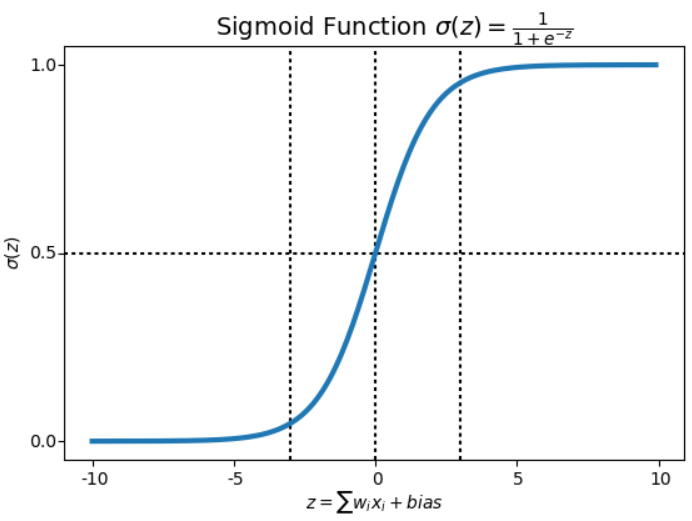

Почему это удобно:

- $\sigma(z)$ монотонна: чем дальше точка в сторону класса 1 (чем больше $z$), тем ближе вероятность к 1;
- чем дальше в сторону класса 0 (чем меньше $z$), тем ближе вероятность к 0;
- около границы $(z\approx 0)$ вероятность естественно близка к $0.5$.

Таким образом, логистическая регрессия сохраняет **линейную геометрию границы**, но даёт **гладкую вероятностную** интерпретацию уверенности.

### 3. Эквивалентная интерпретация: линейны лог-шансы

Ту же модель удобно читать через **логиты** (лог-шансы). Если обозначить $p=P(y=1\mid x)$, то
$$
\log\frac{p}{1-p}=w^\top x+b.
$$
То есть логистическая регрессия утверждает: **лог-шансы класса 1 — линейная функция признаков**.

Из этого сразу следует практическая интерпретация коэффициентов: увеличение признака $x_j$ на 1 (при прочих равных) изменяет лог-шансы на $w_j$ и умножает шансы на $e^{w_j}$.

### **Вопросы**

<details>
<summary><b>Вопрос 1.</b> Какие точки имеют вероятность <code>P(y=1|x)=0.5</code>?</summary>

Те, для которых скор <code>z = wᵀx + b = 0</code>. То есть они лежат на гиперплоскости (границе решения).
</details>

<details>
<summary><b>Вопрос 2.</b> Что означает направление вектора <code>w</code>?</summary>

<code>w</code> перпендикулярен (нормален) гиперплоскости. Двигаясь вдоль <code>w</code>, мы быстрее всего увеличиваем <code>z</code>, а значит и вероятность класса 1.
</details>

<details>
<summary><b>Вопрос 3.</b> Зачем нужна сигмоида?</summary>

Нам нужно уметь превращать скор <code>z ∈ ℝ</code> в число от 0 до 1, причём так, чтобы порядок сохранялся (монотонность): больший скор ⇒ большая вероятность. Сигмоида — самый простой гладкий монотонный способ это сделать.
</details>

<details>
<summary><b>Вопрос 4.</b> Почему иногда говорят про «лог-шансы»?</summary>

Потому что у логистической регрессии линейны именно лог-шансы:
<code>log(p/(1-p)) = wᵀx + b</code>.
Это удобно: вклад каждого признака в «склонность» к классу 1 интерпретируется как линейное слагаемое.
</details>


## Логистическая регрессия: обучение базовой модели

Используя LLM для генерации кода:
1. Обучите `LogisticRegression(random_state=42)` на тех же `X_train, y_train`.
2. Перед обучением примените `StandardScaler()` (через `Pipeline`).
3. Выведите коэффициенты $w$, свободный член $b$ и `accuracy` на тесте.


In [ ]:
#TODO


w: [-1.51794619  3.47039265]
b: -0.6907753048745999
Accuracy (LogReg): 0.8888888888888888


Должно получиться примерно следующее:
- $w: [-1.5179~~~3.4704]$
- $b: -0.6908$
- $Accuracy: 0.8889$

### Визуализация решающей границы

Сравните границу логистической регрессии с kNN. Аналогичным образом с помощью LLM напишите код, который ее визуализирует. Обратите внимание, она должна получиться **линейной** (прямая на плоскости).

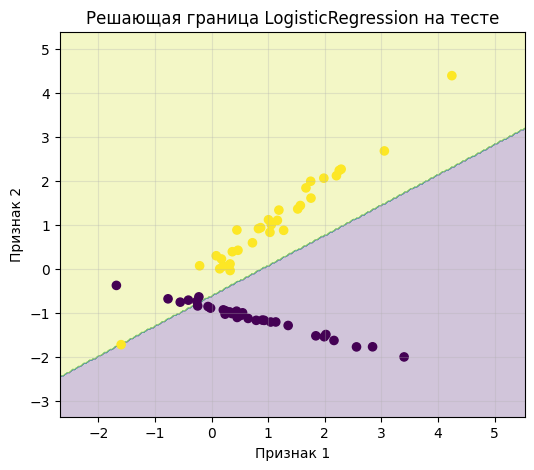

In [ ]:
#TODO


## Оценка модели и метрики

Когда мы обучили классификатор, хочется ответить на вопрос: **насколько хорошо он работает**.  
Самая простая метрика — `accuracy`, но она легко вводит в заблуждение:

- при **несбалансированных классах** (класс 1 редкий) можно получить высокую `accuracy`, всегда предсказывая 0;
- иногда ошибки разной природы стоят по‑разному: **FN** (пропустить событие) и **FP** (лишний раз сработать) могут иметь разную цену.

### Матрица ошибок (confusion matrix)

Чтобы интуитивно понимать метрики, удобно начать с 4 чисел:

|                     | Истина: 1 | Истина: 0 |
|---|---:|---:|
| **Предсказали 1** | TP | FP |
| **Предсказали 0** | FN | TN |

- **TP** (true positive): нашли «единицу» правильно  
- **FP** (false positive): «ложная тревога» — предсказали 1, но истина 0  
- **FN** (false negative): «пропуск» — предсказали 0, но истина 1  
- **TN** (true negative): правильно сказали 0

### Частые метрики из матрицы

 - **Accuracy (доля верных классификаций)**  
  $$
  \mathrm{accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
  $$
  Доля объектов, для которых предсказание совпало с истинной меткой (эмпирическая оценка $P(\hat y = y)$).
- **Precision (точность по положительному классу)**  
  $$
  \mathrm{precision}=\frac{TP}{TP+FP}
  $$
  Доля истинно положительных среди всех предсказанных положительных (эмпирическая оценка $P(y=1\mid \hat y=1)$).

- **Recall (полнота, чувствительность, TPR)**  
  $$
  \mathrm{recall}=\frac{TP}{TP+FN}
  $$
  Доля объектов положительного класса, корректно предсказанных как положительные (эмпирическая оценка $P(\hat y=1\mid y=1)$).

- **F1-score**  
  $$
  F_1=\frac{2\,\mathrm{precision}\cdot \mathrm{recall}}{\mathrm{precision}+\mathrm{recall}}
  $$
  Гармоническое среднее precision и recall; принимает высокие значения только когда обе величины высоки.
<details>
<summary><b>Небольшая тренировка</b>
Попробуйте посчитать метрики на бумаге.</summary>

Пусть: TP=40, FP=10, FN=20, TN=930 (всего 1000 объектов).

1) Accuracy = (TP+TN)/N = (40+930)/1000 = 0.97  
2) Precision = 40/(40+10) = 0.80  
3) Recall = 40/(40+20) = 0.667  
4) F1 = 2·(0.8·0.667)/(0.8+0.667) ≈ 0.727

Важно: при высокой accuracy (0.97) модель всё равно пропускает 1/3 положительных случаев (recall ~0.67).
</details>

Теперь посчитаем метрики на наших данных.

С помощью LLM сгенерируйте код, который:
1. Посчитает `precision`, `recall`, `f1`.
2. Построит `confusion matrix`.
3. Выведет `classification_report`.


Accuracy : 0.8888888888888888
Precision: 0.8333333333333334
Recall   : 0.967741935483871
F1       : 0.8955223880597015

              precision    recall  f1-score   support

           0      0.963     0.812     0.881        32
           1      0.833     0.968     0.896        31

    accuracy                          0.889        63
   macro avg      0.898     0.890     0.888        63
weighted avg      0.899     0.889     0.888        63



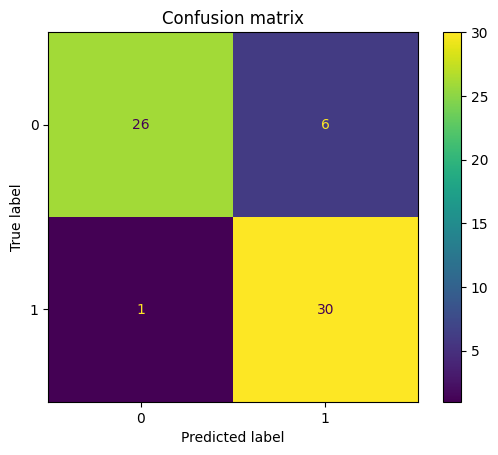

In [ ]:
#TODO

Должно получиться примерно следующее:
- $Accuracy : 0.8889$
- $Precision: 0.8333$
- $Recall   : 0.9677$
- $F1       : 0.8955$


### Вопрос

* Какой метрике вы бы доверяли больше для **медицины**? А для **спама**?


### Ответ

В медицине часто критично **не пропустить** заболевание ⇒ важен `recall` (минимизируем FN). В антиспаме часто важнее не помечать важные письма как спам ⇒ важен `precision` (минимизируем FP).

## Порог классификации и вероятности

Логистическая регрессия выдаёт оценку вероятности положительного класса:
$$
p(x)=P(y=1\mid x)\quad\text{(в sklearn — `predict_proba`)}.
$$

Чтобы получить дискретное решение $\hat y\in\{0,1\}$, выбирают порог $t\in[0,1]$ и применяют правило:
$$
\hat y=
\begin{cases}
1, & p(x)\ge t,\\
0, & p(x)< t.
\end{cases}
$$

Выбор порога напрямую влияет на баланс ошибок и метрик качества:

- При уменьшении порога $t$ модель чаще относит объекты к классу 1:  
  обычно возрастает **полнота** (*recall*), но снижается **точность** (*precision*) из-за роста числа ложноположительных решений.

- При увеличении порога $t$ модель реже относит объекты к классу 1:  
  обычно возрастает **точность** (*precision*), но снижается **полнота** (*recall*) из-за роста числа ложноотрицательных решений.

**Замечание.** Иногда можно улучшить выбранную метрику, не изменяя модель, — за счёт подбора порога $t$.
Поэтому сравнение моделей корректно выполнять вместе с указанием целевой метрики и способа выбора порога.

С помощью LLM сгенерируйте код, который позволит:
1. Получить вероятности класса 1.
2. Попробовать разные пороги, например `0.3`, `0.5`, `0.7`.
3. Сравнить `precision/recall` для разных порогов.


In [ ]:
#TODO

{'threshold': 0.3, 'precision': 0.775, 'recall': 1.0, 'f1': 0.8732394366197183, 'accuracy': 0.8571428571428571}
{'threshold': 0.5, 'precision': 0.8333333333333334, 'recall': 0.967741935483871, 'f1': 0.8955223880597015, 'accuracy': 0.8888888888888888}
{'threshold': 0.7, 'precision': 0.9354838709677419, 'recall': 0.9354838709677419, 'f1': 0.9354838709677419, 'accuracy': 0.9365079365079365}


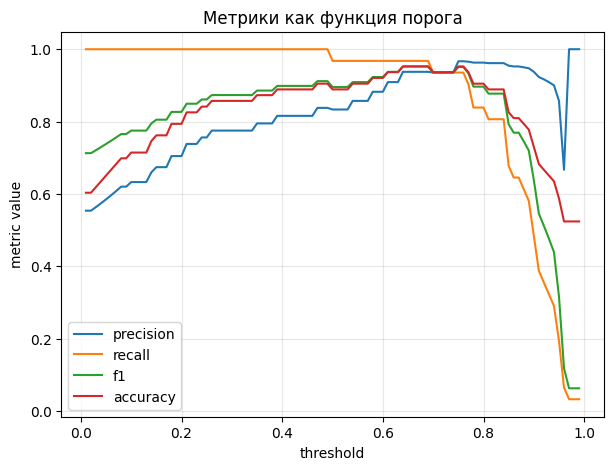

In [ ]:
#TODO

# Подумайте: какая метрика “побеждает” при высоких порогах? при низких?


### **Вопросы**

<details>
<summary><b>Вопрос 1.</b> Почему при очень низком пороге recall обычно близок к 1?</summary>

Потому что модель почти всегда говорит “1”, а значит почти все настоящие единицы будут “пойманы” (FN почти нет). Но при этом FP становится много, поэтому precision падает.
</details>

<details>
<summary><b>Вопрос 2.</b> Как выбрать порог “правильно”?</summary>

Через цель задачи. Два частых подхода:

1) **Оптимизация метрики** (например, выбрать порог, дающий максимум F1 на валидации).  
2) **Ограничение на ошибку**: например, “recall ≥ 0.95”, а среди порогов, которые это дают, выбрать тот, где precision максимален.

Главное — подбирать порог на **валидации**, а не на тесте.
</details>


## ROC‑AUC и PR‑AUC

Иногда мы хотим сравнивать модели **без выбора конкретного порога** (или до того, как мы решили, какой порог нужен).  
Для этого смотрят кривые, которые “пробегают” все пороги.

### ROC‑кривая
ROC строится по точкам `(FPR, TPR)` при разных порогах:
- `TPR = recall = TP/(TP+FN)` — доля найденных единиц
- `FPR = FP/(FP+TN)` — доля ложных тревог среди нулей

**ROC‑AUC** можно интерпретировать так: это вероятность, что модель поставит **более высокий скор** случайной единице, чем случайному нулю (ranking‑интерпретация).

### Precision‑Recall кривая
PR‑кривая строится по точкам `(recall, precision)` при разных порогах.

Практическое правило, когда какую кривую лучше использовать: при **сильном дисбалансе** (единиц мало) PR‑кривая и PR‑AUC часто более информативны, чем ROC.

С помощью LLM:
1. Посчитайте `roc_auc_score`.
2. Постройте ROC‑кривую.
3. Посчитайте PR‑AUC (площадь под Precision‑Recall кривой).


ROC-AUC: 0.9647177419354839


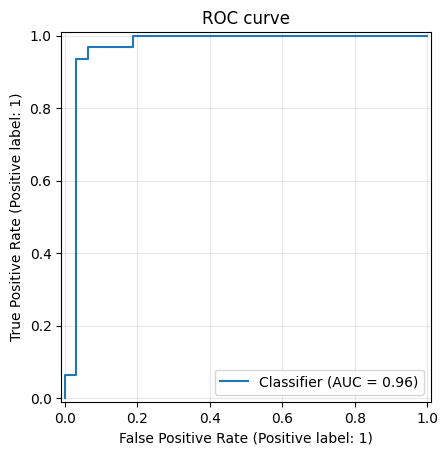

PR-AUC: 0.9180781846284646


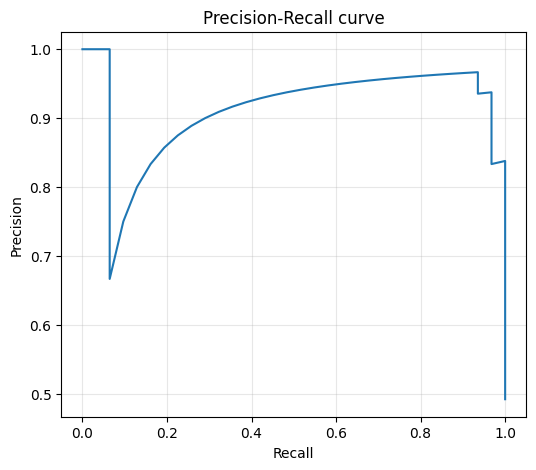

In [ ]:
#TODO

<details>
<summary><b>Вопрос.</b> Почему ROC‑AUC может быть “высоким”, даже если модель бесполезна на редком классе?</summary>

ROC-AUC может оставаться высоким даже тогда, когда модель практически непригодна для работы с редким (положительным) классом, по следующей причине.

ROC-кривая строится по паре величин TPR и FPR, где
$$
\mathrm{FPR}=\frac{FP}{FP+TN}.
$$
В задачах с сильным дисбалансом отрицательных примеров обычно очень много, поэтому знаменатель $FP+TN$ велик. В результате даже заметное число ложноположительных срабатываний $FP$ в абсолютном выражении может давать небольшое значение FPR. Это делает ROC-кривую (и ROC-AUC) менее чувствительной к «стоимости» ложных тревог при редком положительном классе.

PR-кривая в таких условиях часто более информативна, поскольку использует precision
$$
\mathrm{precision}=\frac{TP}{TP+FP},
$$
которая напрямую зависит от числа ложноположительных срабатываний: рост $FP$ немедленно снижает precision. Поэтому при редком положительном классе PR-AUC и связанные метрики обычно лучше отражают практическую полезность модели для обнаружения класса 1.
</details>


## Нелинейность

Не всегда классы разделимы прямой. Рассмотрим классический датасет `moons`.

1. Сгенерируйте данные `make_moons`.
2. Обучите логистическую регрессию.
3. Визуализируйте решающую границу.

**Сделайте вывод:** хватает ли линейной границы?


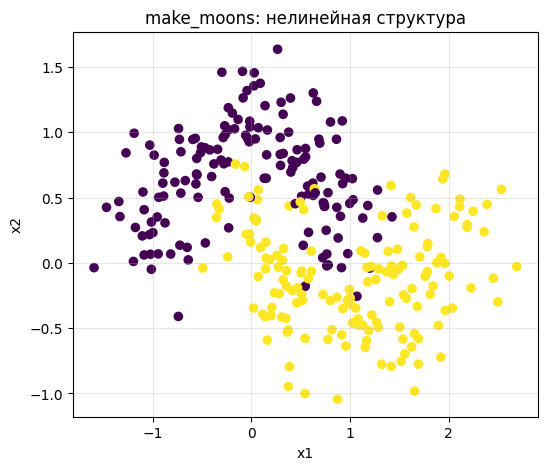

Accuracy: 0.8633333333333333


In [ ]:
#TODO

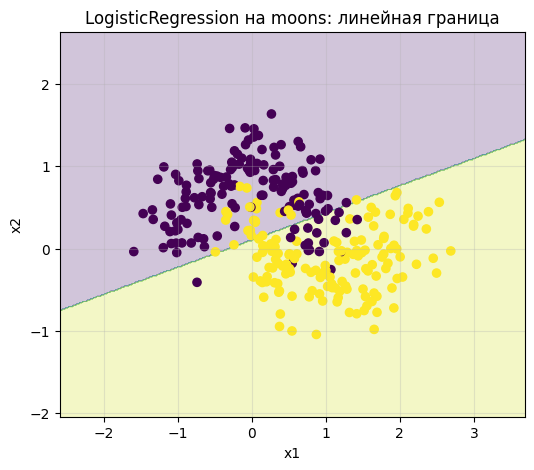

In [ ]:
# Визуализация решающей границы на moons
#TODO


### Ответ


На `moons` классы **нелинейно** разделимы, поэтому линейная модель (логистическая регрессия без дополнительных признаков) будет ошибаться: она может провести только прямую/гиперплоскость.

Есть два популярных пути:
1. **Сделать признаки нелинейными** (например, полиномиальные признаки) и оставить простую модель.
2. Использовать модель, которая имеет нелинейность «внутри» (например, деревья решений, случайный лес, градиентный бустинг и т.д.).

### Реализация

Добавим полиномиальные признаки и сравним качество.

С помощью LLM:
1. Соберите `Pipeline(StandardScaler -> PolynomialFeatures -> LogisticRegression)`.
2. Попробуйте степени 2 и 5.
3. Сравните метрику accuracy.

In [ ]:
#TODO

degree=2 accuracy: 0.8633333333333333
degree=5 accuracy: 0.9166666666666666


Должно получиться примерно следующее:
- degree=2 accuracy: 0.8633
- degree=5 accuracy: 0.9167


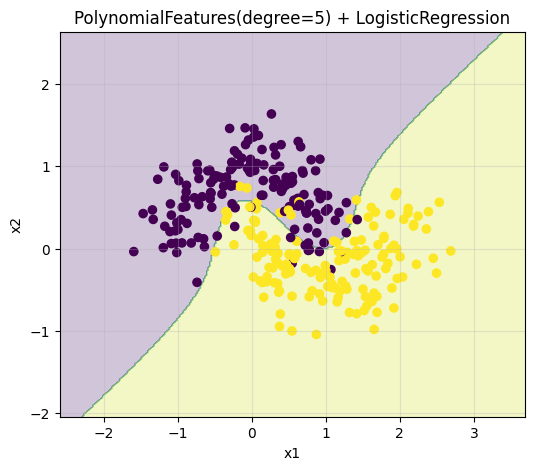

In [ ]:
# Решающее поле для degree=5
#TODO


## Переобучение

Полином высокой степени может подстраиваться под сложные границы и начать **переобучаться**.

С помощью LLM:
1. Разделите `moons` на train/test в соотношении 70/30, и используя стратификацию.
2. Обучите модели со степенями 2, 5, 10.
3. Сравните качество на train и test.

Подумайте: **как распознать переобучение?**

In [ ]:
#TODO


degree=2: train=0.871, test=0.856
degree=5: train=0.929, test=0.889
degree=10: train=0.924, test=0.900


Должно получиться примерно следующее:
- degree=2: train=0.871, test=0.856
- degree=5: train=0.929, test=0.889
- degree=10: train=0.924, test=0.900

### Ответ

Если `train` сильно лучше, чем `test`, это сигнал переобучения.

Чтобы бороться с переобучением, обычно используют:
- больше данных
- регуляризацию
- ограничение сложности модели (например, степень полинома)
- кросс‑валидацию для подбора гиперпараметров

## Регуляризация в логистической регрессии

В `LogisticRegression` параметр `C` — это обратная сила регуляризации:
- маленький `C` ⇒ сильнее регуляризация ⇒ проще граница
- большой `C` ⇒ слабее регуляризация ⇒ сложнее граница

С помощью LLM:
1. Для `degree=10` попробуйте `C = 0.1, 1, 10`.
2. Сравните качество на тесте.

In [ ]:
#TODO

C=0.1: test=0.867
C=1.0: test=0.900
C=10.0: test=0.889


Должно получиться примерно следующее:
- C=0.1: test=0.867
- C=1.0: test=0.900
- C=10.0: test=0.889

## Итоги

В этом блокноте мы:
- интуитивно разобрались с классификацией на примере **kNN**
- построили базовый линейный классификатор (**логистическую регрессию**) и увидели её решающую границу
- разобрались с метриками качества (`precision/recall/F1`, `confusion matrix`, `classification_report`)
- поняли, зачем нужны ROC‑AUC и PR‑AUC и как порог влияет на `precision/recall`
- увидели нелинейность, переобучение и регуляризацию на примере полиномиальных признаков
- посмотрели на дисбаланс классов

**Домашняя практика:**
1. Для kNN попробуйте разные `k` (1, 3, 5, 15) и сравните не только `accuracy`, но и `precision/recall` при дисбалансе.
2. Для датасета `moons` подберите степень полинома и параметр `C` регуляризации, сравните `train/test`.